# Инференс с разбиением изображения по частям

# Библиотеки

In [1]:
from ultralytics import YOLO
from PIL import Image
from patched_yolo_infer import (
    MakeCropsDetectThem,
    CombineDetections,
    visualize_results_usual_yolo_inference,
    visualize_results,
)

import cv2
import matplotlib.pyplot as plt


# Константы

In [2]:
PATH_BEST = '../runs/detect/train3/weights/best.pt'
PATH_TEST_IMAGES = './DataSet/NewDataAll/Test/images'
PATH_TEST_LABELS = './DataSet/NewDataAll/Test/labels'
SAVE_RESULT = './Result/'

In [3]:
model = YOLO(PATH_BEST)

# На фотографии

In [ ]:


NAME = '730'
results = model(f'{PATH_TEST_IMAGES}/{NAME}.jpg')  # Замените на путь к вашему изображению

# # Визуализация и сохранение результата
# for result in results:
#     result.show()  # Отобразить изображение с детекцией
#     result.save(SAVE_RESULT)  # Сохранить результат


image 1/1 d:\Nsu\SearchPersonAI\AI\DataSet\NewDataAll\Test\images\730.jpg: 480x640 1 item, 131.7ms
Speed: 2.6ms preprocess, 131.7ms inference, 1.6ms postprocess per image at shape (1, 3, 480, 640)


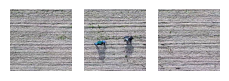

Number of generated images: 3


In [4]:
img = cv2.imread(f'./my_100065.jpg')

element_crops = MakeCropsDetectThem(
    image=img,
    model_path=PATH_BEST,
    segment=False,
    show_crops=True,
    shape_x=640,
    shape_y=640,
    overlap_x=10,
    overlap_y=10,
    conf=0.5,
    iou=0.7,
    classes_list=[0],
)
result = CombineDetections(element_crops, nms_threshold=0.1)

YOLO-Patch-Based-Inference:


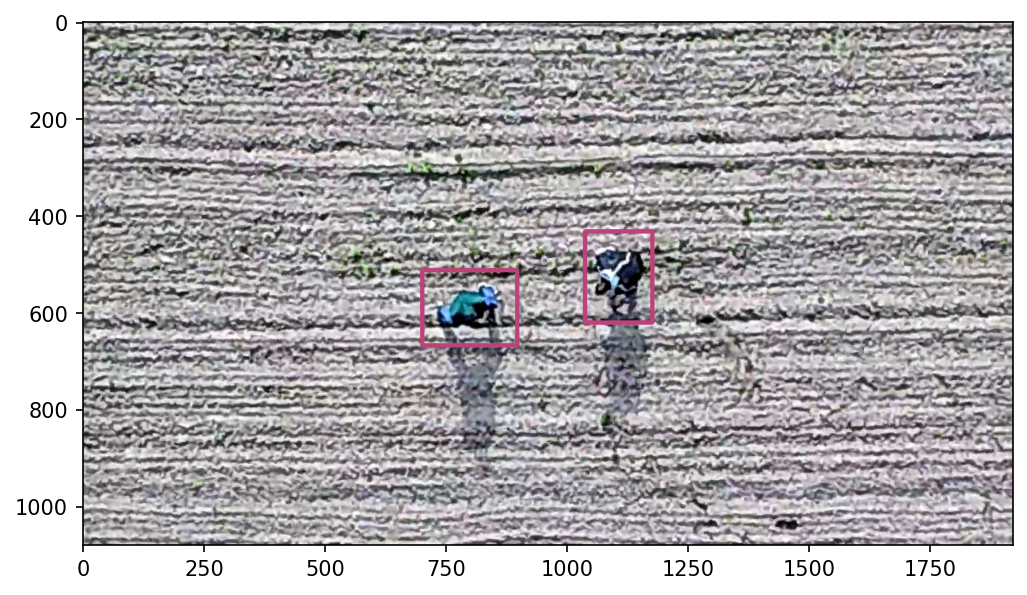

In [5]:
# print('Basic yolo inference:')
# visualize_results_usual_yolo_inference(
#     img,
#     model=model,
#     imgsz=640,
#     conf=0.5,
#     iou=0.7,
#     thickness=8,
#     show_boxes=True,
#     delta_colors=3,
#     show_class=False,
#     axis_off=False
# )

print('YOLO-Patch-Based-Inference:')
visualize_results(
    img=result.image,
    confidences=result.filtered_confidences,
    boxes=result.filtered_boxes,
    classes_ids=result.filtered_classes_id,
    classes_names=result.filtered_classes_names,
    thickness=8,
    show_boxes=True,
    delta_colors=3,
    show_class=False,
    axis_off=False
)

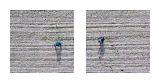

Number of generated images: 2
Before nms:


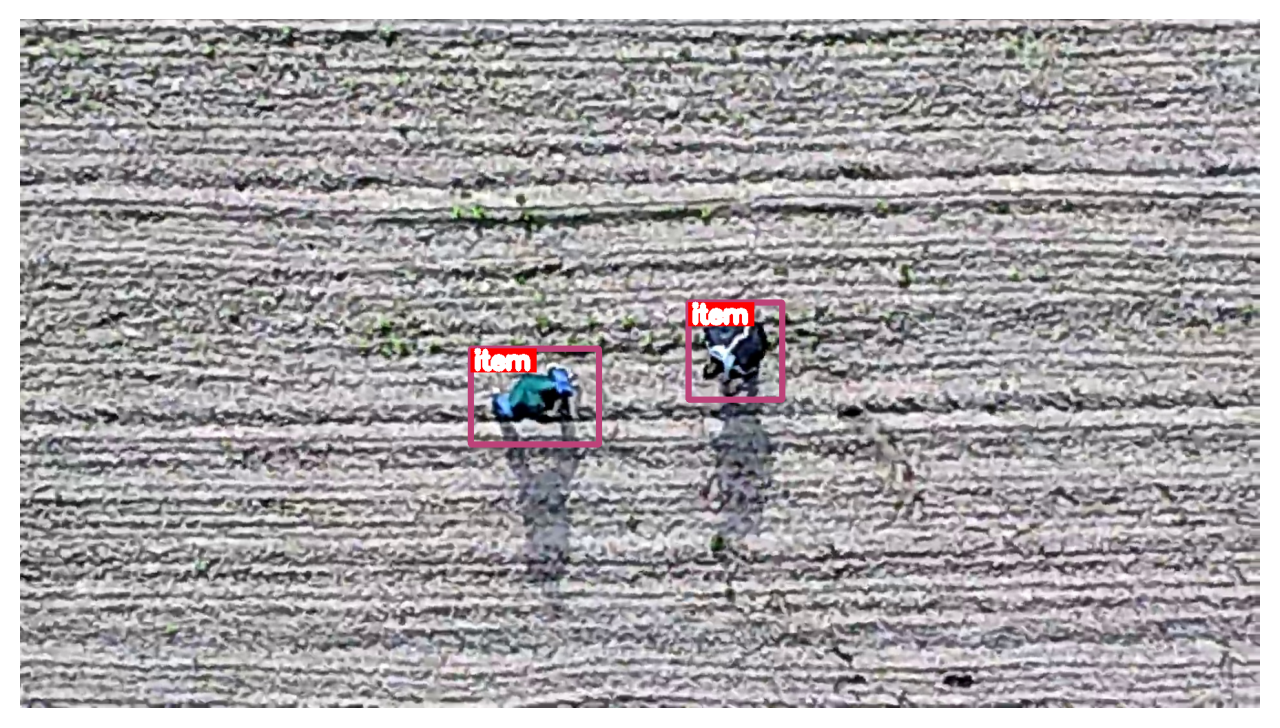

After nms:


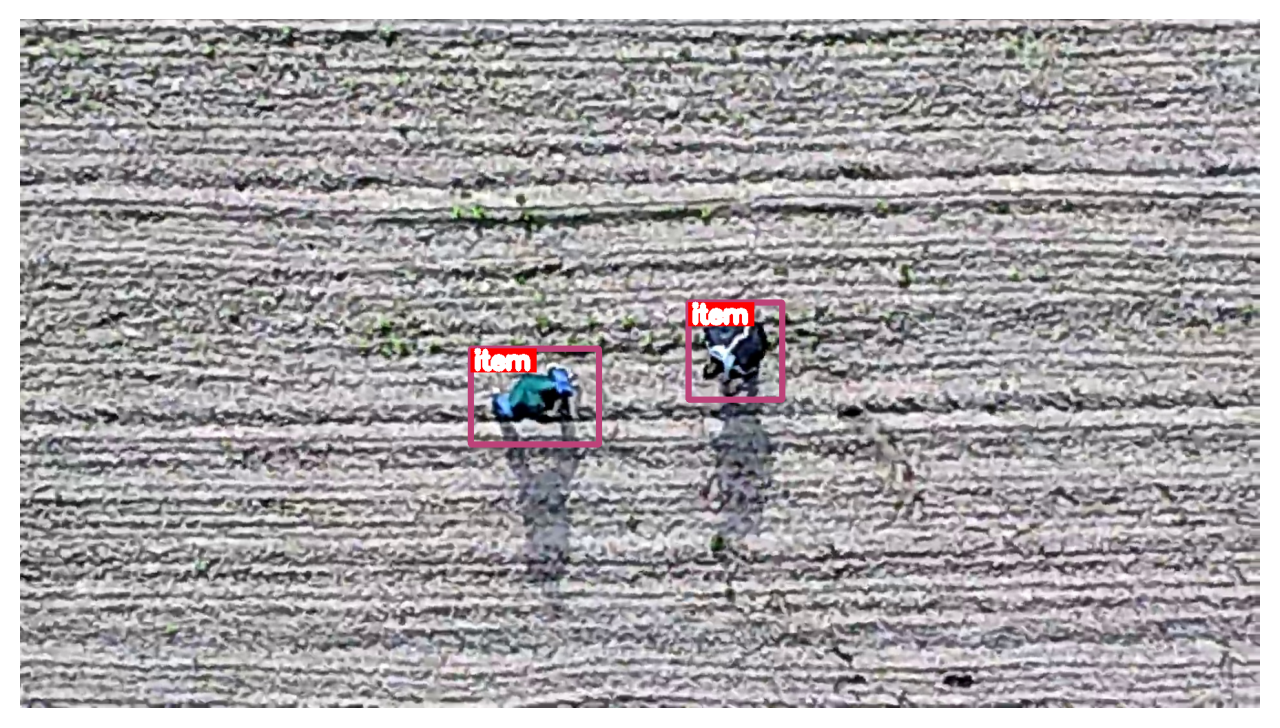

In [6]:
element_crops = MakeCropsDetectThem(
    image=img,
    model_path=PATH_BEST,
    segment=False,
    show_crops=True,
    shape_x=1000,
    shape_y=1000,
    overlap_x=20,
    overlap_y=20,
    conf=0.5,
    iou=0.5,
    classes_list=[0],
    resize_initial_size=False,
)
result = CombineDetections(element_crops, nms_threshold=0.1)

print('Before nms:')
visualize_results(
    img=result.image,
    confidences=result.detected_conf_list_full,
    boxes=result.detected_xyxy_list_full,
    classes_ids=result.detected_cls_id_list_full,
    classes_names=result.detected_cls_names_list_full,
    thickness=8,
    font_scale=1.2,
    show_boxes=True,
    delta_colors=3,
    dpi=200,
)

print('After nms:')
visualize_results(
    img=result.image,
    confidences=result.filtered_confidences,
    boxes=result.filtered_boxes,
    classes_ids=result.filtered_classes_id,
    classes_names=result.filtered_classes_names,
    thickness=8,
    font_scale=1.2,
    show_boxes=True,
    delta_colors=3,
    dpi=200,
)